In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
w1 = np.random.randn(2, 4)
b1 = np.random.randn(4)
x = np.random.randn(10, 2)
h = np.matmul(x, w1) + b1

In [4]:
def sigmoid(x):
    return 1 / ( 1 + np.exp(-x))

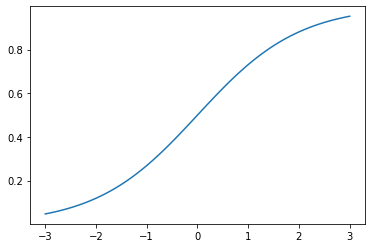

In [6]:
x = np.linspace(-3, 3, 100)
y = sigmoid(x)
plt.plot(x, y)
plt.show()

In [8]:
x = np.random.randn(10, 2)
w1 = np.random.randn(2, 4)
b1 = np.random.randn(4)
w2 = np.random.randn(4, 3)
b2 = np.random.randn(3)

h = np.matmul(x, w1) + b1
a = sigmoid(h)
s = np.matmul(a, w2) + b2

In [10]:
class Sigmoid:
    def __init__(self):
        self.params = []
        
    def forward(self, x):
        return 1 / (1 + np.exp(-x))

In [11]:
class Affine:
    def __init__(self, w, b):
        self.params = [w, b]
        
    def forward(self, x):
        w, b = self.params
        out = np.matmul(x, w) + b
        return out

In [14]:
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        i, h, o = input_size, hidden_size, output_size
        
        # 가중치와 편향 초기화
        w1 = np.random.randn(i, h)
        b1 = np.random.randn(h)
        w2 = np.random.randn(h, o)
        b2 = np.random.randn(o)
        
        # 계층 생성
        self.layers = [
            Affine(w1, b1),
            Sigmoid(),
            Affine(w2, b2)
        ]
        
        # 모든 가중치를 리스트에 모은다
        self.params = []
        for layer in self.layers:
            self.params += layer.params
            
    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

In [15]:
x = np.random.randn(10, 2)
model = TwoLayerNet(2, 4, 3)
s = model.predict(x)

In [17]:
d, n = 8, 7
x = np.random.randn(1, d)
y = np.repeat(x, n ,axis=0)
dy = np.random.randn(n, d)
dx = np.sum(dy, axis=0, keepdims=True)

In [18]:
class MatMul:
    def __init__(self, w):
        self.params = [w]
        self.grads = [np.zeros_like(w)]
        self.x = None
        
    def forward(self, x):
        w, = self.params
        out = np.matmul(x, w)
        self.x = x
        return out
    
    def backward(self, dout):
        w, = self.params
        dx = np.matmul(dout, w.T)
        dw = np.matmul(self.x.T, dout)
        self.grads[0][...] = dw
        return dx

In [21]:
class Sigmoid:
    def __init__(self):
        self.params, self.grads = [], []
        self.out = None
        
    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out
    
    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out
        return dx

In [25]:
class Affine:
    def __init__(self, w, b):
        self.params = [w, b]
        self.grads = [np.zeros_like(w), np.zeros_like(b)]
        self.x = None
        
    def forward(self, x):
        w, b = self.params
        out = np.matmul(x, w) + b
        self.x = x
        return out
    
    def backward(self, dout):
        w, b = self.params
        dx = np.matmul(dout, w.T)
        dw = np.matmul(self.x.T, dout)
        db = np.sum(dout, axis=0)
        
        self.grads[0][...] = dw
        self.grads[1][...] = db
        return dx

In [26]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
        
    def update(self, params, grads):
        for i in range(len(params)):
            params[i] -= self.lr * grads[i]

In [27]:
import sys
sys.path.append('..')
from dataset import spiral

x, t = spiral.load_data()
print(x.shape)
print(t.shape)

(300, 2)
(300, 3)


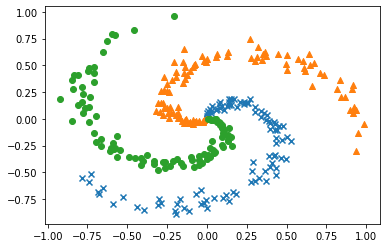

In [44]:
plt.scatter(x[:101,0], x[:101,1], marker='x')
plt.scatter(x[101:201,0], x[101:201,1], marker='^')
plt.scatter(x[201:,0], x[201:,1], marker='o')
plt.show()

In [51]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import Affine, Sigmoid, SoftmaxWithLoss

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        i, h, o = input_size, hidden_size, output_size
        
        # 가중치와 편향 초기화
        w1 = 0.01 * np.random.randn(i ,h)
        b1 = np.zeros(h)
        w2 = 0.01 * np.random.randn(h, o)
        b2 = np.zeros(o)
        
        # 계층 생성
        self.layers = [
            Affine(w1, b1),
            Sigmoid(),
            Affine(w2, b2)
        ]
        self.loss_layer = SoftmaxWithLoss()
        
        # 모든 가중치와 기울기를 리스트에 모은다
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads
            
    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x
        
    def forward(self, x, t):
        score = self.predict(x)
        loss = self.loss_layer.forward(score, t)
        return loss
    
    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

In [57]:
import sys
sys.path.append('..')
import numpy as np
from common.optimizer import SGD
from dataset import spiral
import matplotlib.pyplot as plt
from two_layer_net import TwoLayerNet

# 하이퍼파라미터 설정
max_epoch = 300
batch_size = 30
hidden_size = 10
learning_rate = 1.0

# 데이터 읽기, 모델과 옵티마이저 생성
x, t = spiral.load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, output_size=3)
optimizer = SGD(lr=learning_rate)

# 학습에 사용하는 변수
data_size = len(x)
max_iters = data_size // batch_size
total_loss = 0
loss_count = 0
loss_list = []

for epoch in range(max_epoch):
    # 데이터 뒤섞기
    idx = np.random.permutation(data_size)
    x = x[idx]
    t = t[idx]
    
    for iters in range(max_iters):
        batch_x = x[iters * batch_size : (iters + 1) * batch_size]
        batch_t = t[iters * batch_size : (iters + 1) * batch_size]
        
        # 기울기를 구해 매개변수 갱신
        loss = model.forward(batch_x, batch_t)
        model .backward()
        optimizer.update(model.params, model.grads)
        
        total_loss += loss
        loss_count += 1
        
        # 정기적으로 학습 경과 출력
        if (iters + 1) % 10 == 0:
            avg_loss = total_loss / loss_count
            print('| 에폭 %d | 반복 %d | %d | 손실 %.2f' % (epoch + 1, iters + 1, max_iters, avg_loss))
            loss_list.append(avg_loss)
            total_losss, loss_count = 0, 0

| 에폭 1 | 반복 10 | 10 | 손실 1.13
| 에폭 2 | 반복 10 | 10 | 손실 2.25
| 에폭 3 | 반복 10 | 10 | 손실 3.37
| 에폭 4 | 반복 10 | 10 | 손실 4.48
| 에폭 5 | 반복 10 | 10 | 손실 5.60
| 에폭 6 | 반복 10 | 10 | 손실 6.73
| 에폭 7 | 반복 10 | 10 | 손실 7.89
| 에폭 8 | 반복 10 | 10 | 손실 9.00
| 에폭 9 | 반복 10 | 10 | 손실 10.12
| 에폭 10 | 반복 10 | 10 | 손실 11.25
| 에폭 11 | 반복 10 | 10 | 손실 12.37
| 에폭 12 | 반복 10 | 10 | 손실 13.47
| 에폭 13 | 반복 10 | 10 | 손실 14.56
| 에폭 14 | 반복 10 | 10 | 손실 15.64
| 에폭 15 | 반복 10 | 10 | 손실 16.68
| 에폭 16 | 반복 10 | 10 | 손실 17.72
| 에폭 17 | 반복 10 | 10 | 손실 18.67
| 에폭 18 | 반복 10 | 10 | 손실 19.59
| 에폭 19 | 반복 10 | 10 | 손실 20.52
| 에폭 20 | 반복 10 | 10 | 손실 21.38
| 에폭 21 | 반복 10 | 10 | 손실 22.23
| 에폭 22 | 반복 10 | 10 | 손실 23.05
| 에폭 23 | 반복 10 | 10 | 손실 23.84
| 에폭 24 | 반복 10 | 10 | 손실 24.63
| 에폭 25 | 반복 10 | 10 | 손실 25.45
| 에폭 26 | 반복 10 | 10 | 손실 26.23
| 에폭 27 | 반복 10 | 10 | 손실 26.98
| 에폭 28 | 반복 10 | 10 | 손실 27.75
| 에폭 29 | 반복 10 | 10 | 손실 28.53
| 에폭 30 | 반복 10 | 10 | 손실 29.28
| 에폭 31 | 반복 10 | 10 | 손실 30.06
| 에폭 32 | 반복 10 | 10 | 손실

| 에폭 266 | 반복 10 | 10 | 손실 110.49
| 에폭 267 | 반복 10 | 10 | 손실 110.61
| 에폭 268 | 반복 10 | 10 | 손실 110.73
| 에폭 269 | 반복 10 | 10 | 손실 110.84
| 에폭 270 | 반복 10 | 10 | 손실 110.96
| 에폭 271 | 반복 10 | 10 | 손실 111.08
| 에폭 272 | 반복 10 | 10 | 손실 111.20
| 에폭 273 | 반복 10 | 10 | 손실 111.31
| 에폭 274 | 반복 10 | 10 | 손실 111.43
| 에폭 275 | 반복 10 | 10 | 손실 111.55
| 에폭 276 | 반복 10 | 10 | 손실 111.66
| 에폭 277 | 반복 10 | 10 | 손실 111.79
| 에폭 278 | 반복 10 | 10 | 손실 111.90
| 에폭 279 | 반복 10 | 10 | 손실 112.01
| 에폭 280 | 반복 10 | 10 | 손실 112.13
| 에폭 281 | 반복 10 | 10 | 손실 112.24
| 에폭 282 | 반복 10 | 10 | 손실 112.36
| 에폭 283 | 반복 10 | 10 | 손실 112.47
| 에폭 284 | 반복 10 | 10 | 손실 112.58
| 에폭 285 | 반복 10 | 10 | 손실 112.70
| 에폭 286 | 반복 10 | 10 | 손실 112.81
| 에폭 287 | 반복 10 | 10 | 손실 112.92
| 에폭 288 | 반복 10 | 10 | 손실 113.04
| 에폭 289 | 반복 10 | 10 | 손실 113.15
| 에폭 290 | 반복 10 | 10 | 손실 113.27
| 에폭 291 | 반복 10 | 10 | 손실 113.38
| 에폭 292 | 반복 10 | 10 | 손실 113.49
| 에폭 293 | 반복 10 | 10 | 손실 113.60
| 에폭 294 | 반복 10 | 10 | 손실 113.71
| 에폭 295 | 반복 

| 에폭 1 |  반복 10 / 10 | 손실 1.13
| 에폭 2 |  반복 10 / 10 | 손실 1.13
| 에폭 3 |  반복 10 / 10 | 손실 1.12
| 에폭 4 |  반복 10 / 10 | 손실 1.12
| 에폭 5 |  반복 10 / 10 | 손실 1.11
| 에폭 6 |  반복 10 / 10 | 손실 1.14
| 에폭 7 |  반복 10 / 10 | 손실 1.16
| 에폭 8 |  반복 10 / 10 | 손실 1.11
| 에폭 9 |  반복 10 / 10 | 손실 1.12
| 에폭 10 |  반복 10 / 10 | 손실 1.13
| 에폭 11 |  반복 10 / 10 | 손실 1.12
| 에폭 12 |  반복 10 / 10 | 손실 1.11
| 에폭 13 |  반복 10 / 10 | 손실 1.09
| 에폭 14 |  반복 10 / 10 | 손실 1.08
| 에폭 15 |  반복 10 / 10 | 손실 1.04
| 에폭 16 |  반복 10 / 10 | 손실 1.03
| 에폭 17 |  반복 10 / 10 | 손실 0.96
| 에폭 18 |  반복 10 / 10 | 손실 0.92
| 에폭 19 |  반복 10 / 10 | 손실 0.92
| 에폭 20 |  반복 10 / 10 | 손실 0.87
| 에폭 21 |  반복 10 / 10 | 손실 0.85
| 에폭 22 |  반복 10 / 10 | 손실 0.82
| 에폭 23 |  반복 10 / 10 | 손실 0.79
| 에폭 24 |  반복 10 / 10 | 손실 0.78
| 에폭 25 |  반복 10 / 10 | 손실 0.82
| 에폭 26 |  반복 10 / 10 | 손실 0.78
| 에폭 27 |  반복 10 / 10 | 손실 0.76
| 에폭 28 |  반복 10 / 10 | 손실 0.76
| 에폭 29 |  반복 10 / 10 | 손실 0.78
| 에폭 30 |  반복 10 / 10 | 손실 0.75
| 에폭 31 |  반복 10 / 10 | 손실 0.78
| 에폭 32 |  반복 10 

| 에폭 268 |  반복 10 / 10 | 손실 0.12
| 에폭 269 |  반복 10 / 10 | 손실 0.11
| 에폭 270 |  반복 10 / 10 | 손실 0.12
| 에폭 271 |  반복 10 / 10 | 손실 0.12
| 에폭 272 |  반복 10 / 10 | 손실 0.12
| 에폭 273 |  반복 10 / 10 | 손실 0.12
| 에폭 274 |  반복 10 / 10 | 손실 0.12
| 에폭 275 |  반복 10 / 10 | 손실 0.11
| 에폭 276 |  반복 10 / 10 | 손실 0.12
| 에폭 277 |  반복 10 / 10 | 손실 0.12
| 에폭 278 |  반복 10 / 10 | 손실 0.11
| 에폭 279 |  반복 10 / 10 | 손실 0.11
| 에폭 280 |  반복 10 / 10 | 손실 0.11
| 에폭 281 |  반복 10 / 10 | 손실 0.11
| 에폭 282 |  반복 10 / 10 | 손실 0.12
| 에폭 283 |  반복 10 / 10 | 손실 0.11
| 에폭 284 |  반복 10 / 10 | 손실 0.11
| 에폭 285 |  반복 10 / 10 | 손실 0.11
| 에폭 286 |  반복 10 / 10 | 손실 0.11
| 에폭 287 |  반복 10 / 10 | 손실 0.11
| 에폭 288 |  반복 10 / 10 | 손실 0.12
| 에폭 289 |  반복 10 / 10 | 손실 0.11
| 에폭 290 |  반복 10 / 10 | 손실 0.11
| 에폭 291 |  반복 10 / 10 | 손실 0.11
| 에폭 292 |  반복 10 / 10 | 손실 0.11
| 에폭 293 |  반복 10 / 10 | 손실 0.11
| 에폭 294 |  반복 10 / 10 | 손실 0.11
| 에폭 295 |  반복 10 / 10 | 손실 0.12
| 에폭 296 |  반복 10 / 10 | 손실 0.11
| 에폭 297 |  반복 10 / 10 | 손실 0.12
| 에폭 298 |

C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


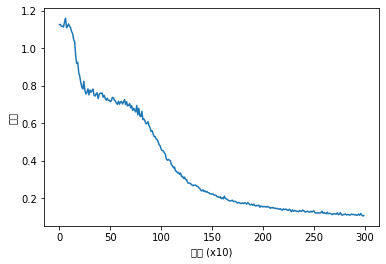

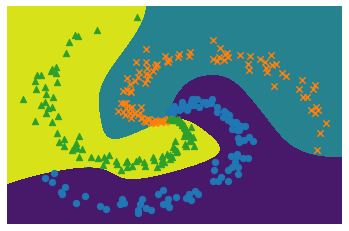

In [56]:
import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
from common.optimizer import SGD
from dataset import spiral
import matplotlib.pyplot as plt
from two_layer_net import TwoLayerNet


# 하이퍼파라미터 설정
max_epoch = 300
batch_size = 30
hidden_size = 10
learning_rate = 1.0

# 데이터 읽기, 모델과 옵티마이저 생성
x, t = spiral.load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, output_size=3)
optimizer = SGD(lr=learning_rate)

# 학습에 사용하는 변수
data_size = len(x)
max_iters = data_size // batch_size
total_loss = 0
loss_count = 0
loss_list = []

for epoch in range(max_epoch):
    # 데이터 뒤섞기
    idx = np.random.permutation(data_size)
    x = x[idx]
    t = t[idx]

    for iters in range(max_iters):
        batch_x = x[iters*batch_size:(iters+1)*batch_size]
        batch_t = t[iters*batch_size:(iters+1)*batch_size]

        # 기울기를 구해 매개변수 갱신
        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)

        total_loss += loss
        loss_count += 1

        # 정기적으로 학습 경과 출력
        if (iters+1) % 10 == 0:
            avg_loss = total_loss / loss_count
            print('| 에폭 %d |  반복 %d / %d | 손실 %.2f'
                  % (epoch + 1, iters + 1, max_iters, avg_loss))
            loss_list.append(avg_loss)
            total_loss, loss_count = 0, 0


# 학습 결과 플롯
plt.plot(np.arange(len(loss_list)), loss_list, label='train')
plt.xlabel('반복 (x10)')
plt.ylabel('손실')
plt.show()

# 경계 영역 플롯
h = 0.001
x_min, x_max = x[:, 0].min() - .1, x[:, 0].max() + .1
y_min, y_max = x[:, 1].min() - .1, x[:, 1].max() + .1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X = np.c_[xx.ravel(), yy.ravel()]
score = model.predict(X)
predict_cls = np.argmax(score, axis=1)
Z = predict_cls.reshape(xx.shape)
plt.contourf(xx, yy, Z)
plt.axis('off')

# 데이터점 플롯
x, t = spiral.load_data()
N = 100
CLS_NUM = 3
markers = ['o', 'x', '^']
for i in range(CLS_NUM):
    plt.scatter(x[i*N:(i+1)*N, 0], x[i*N:(i+1)*N, 1], s=40, marker=markers[i])
plt.show()

| 에폭 1 |  반복 1 / 10 | 시간 0[s] | 손실 1.10
| 에폭 2 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 3 |  반복 1 / 10 | 시간 0[s] | 손실 1.13
| 에폭 4 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 5 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 6 |  반복 1 / 10 | 시간 0[s] | 손실 1.10
| 에폭 7 |  반복 1 / 10 | 시간 0[s] | 손실 1.14
| 에폭 8 |  반복 1 / 10 | 시간 0[s] | 손실 1.16
| 에폭 9 |  반복 1 / 10 | 시간 0[s] | 손실 1.11
| 에폭 10 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 11 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 12 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 13 |  반복 1 / 10 | 시간 0[s] | 손실 1.10
| 에폭 14 |  반복 1 / 10 | 시간 0[s] | 손실 1.09
| 에폭 15 |  반복 1 / 10 | 시간 0[s] | 손실 1.08
| 에폭 16 |  반복 1 / 10 | 시간 0[s] | 손실 1.04
| 에폭 17 |  반복 1 / 10 | 시간 0[s] | 손실 1.03
| 에폭 18 |  반복 1 / 10 | 시간 0[s] | 손실 0.94
| 에폭 19 |  반복 1 / 10 | 시간 0[s] | 손실 0.92
| 에폭 20 |  반복 1 / 10 | 시간 0[s] | 손실 0.92
| 에폭 21 |  반복 1 / 10 | 시간 0[s] | 손실 0.87
| 에폭 22 |  반복 1 / 10 | 시간 0[s] | 손실 0.85
| 에폭 23 |  반복 1 / 10 | 시간 0[s] | 손실 0.80
| 에폭 24 |  반복 1 / 10 | 시간 0[s] | 손실 0.79
| 에폭 25 |  반복 1 / 10 | 시간

| 에폭 278 |  반복 1 / 10 | 시간 0[s] | 손실 0.13
| 에폭 279 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 280 |  반복 1 / 10 | 시간 0[s] | 손실 0.10
| 에폭 281 |  반복 1 / 10 | 시간 0[s] | 손실 0.12
| 에폭 282 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 283 |  반복 1 / 10 | 시간 0[s] | 손실 0.12
| 에폭 284 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 285 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 286 |  반복 1 / 10 | 시간 0[s] | 손실 0.12
| 에폭 287 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 288 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 289 |  반복 1 / 10 | 시간 0[s] | 손실 0.12
| 에폭 290 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 291 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 292 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 293 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 294 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 295 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 296 |  반복 1 / 10 | 시간 0[s] | 손실 0.12
| 에폭 297 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 298 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 299 |  반복 1 / 10 | 시간 0[s] | 손실 0.11
| 에폭 300 |  반복 1 / 10 | 시간 0[s] | 손실 0.11


C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rltjq\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


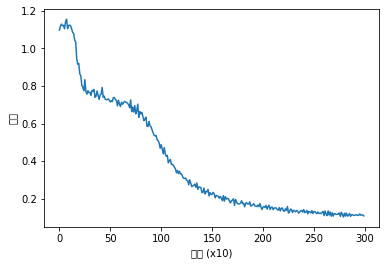

In [59]:
import sys
sys.path.append('..')
from common.optimizer import SGD
from common.trainer import Trainer
from dataset import spiral
from two_layer_net import TwoLayerNet

max_epoch = 300
batch_size = 30
hidden_size = 10
learnings_rate = 1.0

x, t = spiral.load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, output_size=3)
optimizer = SGD(lr=learning_rate)

trainer = Trainer(model, optimizer)
trainer.fit(x, t, max_epoch, batch_size, eval_interval=10)
trainer.plot()

In [60]:
b = np.random.randn(3).astype(np.float32)
b.dtype

dtype('float32')

In [62]:
c = np.random.randn(3).astype('f')
c.dtype

dtype('float32')

In [2]:
import cupy as cp
x = cp.arange(6).reshape(2, 3).astype('f')
x

array([[0., 1., 2.],
       [3., 4., 5.]], dtype=float32)

In [3]:
import sys
sys.path.append('..')
import numpy as np
from common import config

config.GPU = True